---
# SFPPy Example: fitting an arbirary combination of parameters D[i] and k[i]
# from experiments using layerLinks and dynamic simulations.
---

## Example 4: Sensitivity Analysis and Kinetic Data Fitting
---------------------------------------------------------

# **Example4.py: Estimation of D and k from Concentration Kinetics in Food Simulants**
## **Overview**
This script illustrates how **diffusivity (D)** and **partition coefficients (k)** can be estimated from **experimental concentration kinetics** in **food simulants**. The method relies on **layerLink objects**, which allow adjusting simulation parameters dynamically.

The workflow involves:
    1. **Define a monolayer material (P) and a food simulant (F).**
    2. **Enforce a reference partition coefficient (kF = 1) for F**, allowing kP to be interpreted as the **partition coefficient between F and P**.
    3. **Perform a migration simulation** to establish a baseline.
    4. **Generate pseudo-experimental data** with controlled noise levels.
    5. **Evaluate the squared error (`d2 = R - E`)** between simulation (`R`) and experiment (`E`).
    6. **Conduct a sensitivity analysis** by varying D and k to assess their impact.
    7. **Optimize D and k simultaneously** to recover their original values.
    8. **Analyze the goodness of fit and risk of overfitting.**

### **Key Concepts**
- **`layerLink` for parameter linking:** Enables modifying **D** and **k** externally without modifying the base layer object.
- **Migration simulation (`F.migration(P)`)**: Computes mass transfer from P into F.
- **Pseudo-experimental data (`R.pseudoexperiment()`)**: Creates synthetic datasets for validation.
- **Fitting (`R.fit(E)`)**: Automatically adjusts **D** and **k** to best match experimental data.

### **Expected Outcomes**
- **Validation of layerLink objects** for parameter optimization.
- **Comparison of simulated vs. experimental data** to evaluate fit quality.
- **Determination of optimal D and k values** for given experimental conditions.

--------------------------------------------------------
### Summary
--------------------------------------------------------
This script demonstrates **an advanced approach for parameter estimation** in food safety analysis.

@project: SFPPy - SafeFoodPackaging Portal in Python initiative
@author: INRAE\\olivier.vitrac@agroparistech.fr
@licence: MIT

### Dependencies

In [3]:
from patankar.layer import layer, layerLink
from patankar.food import foodlayer

# Reference migration problem
> Migration means desorption from a polymer into a liquid. Three transport properties control mass transfer: diffusivity ($D$), partition coefficient $\frac{k_P}{k_F}$, and the mass transfer resistance $h$.

## Polymer layer: P

In [6]:
P = layer(
    l=(100, "um"),
    D=(1e-10, "cm**2/s"),  # Diffusivity in cm²/s (internally converted to SI)
    C0=1000,  # Initial concentration (arbitrary units)
    k=0.1  # Partition coefficient
)

## Food Layer: F

In [8]:
F = foodlayer(
    contacttime=(10, "days"),
    volume=(1, "L"),
    surfacearea=(6, "dm**2"),
    h=(1e-6, "m/s"),  # Mass transfer coefficient
    CF0=0,  # Initial concentration in the food
    k=1  # Fixed kF, allowing kP to represent kF/P
)

## Create Layer links for the two free paramers: $D$ and $k_P$
> LayerLinks are sparse objects that store the indices and reference values that need to be changed live. Once the layerLinks are attached to P (with attributes `Dlink`, `klink`, `llink`, `C0link`, `Tlink`), any change in the layerLinks will be reflected in the instance of P.
> 
> LayerLinks objects can be manipulated as lists. For instance, if `D` is a layerLink for diffusivities,  `D[i]` will modify the diffusivity value of the layer indexed $i+1$.
>
> In our publications and in SFPPy, layers are indexed 1,2,3... with 1 being the layer of P in contact with F. Layer 0 in our publications is referred to F. Note that in Python, the indices start at 0.

In [10]:
Dreference, kreference = P.D, P.k  # Store original values for comparison
D = layerLink("D", indices=0, values=Dreference)  # Create link for D
k = layerLink("k", indices=0, values=kreference)  # Create link for k
P.Dlink = D  # Attach links to P
P.klink = k

## Reference simulation

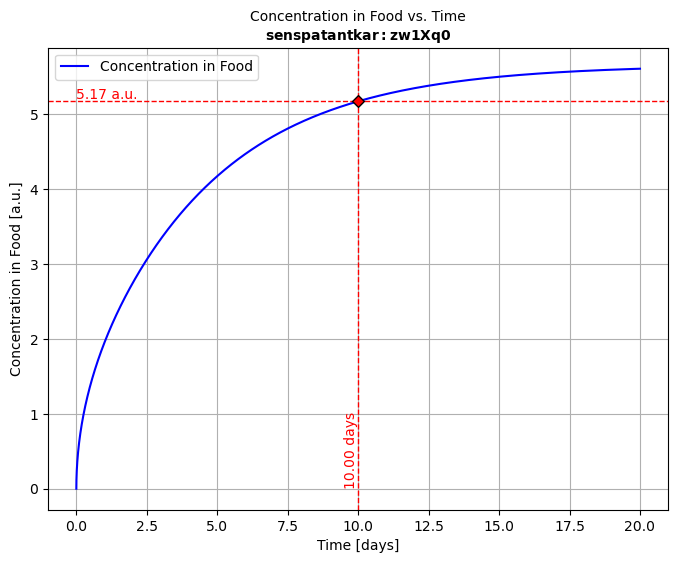

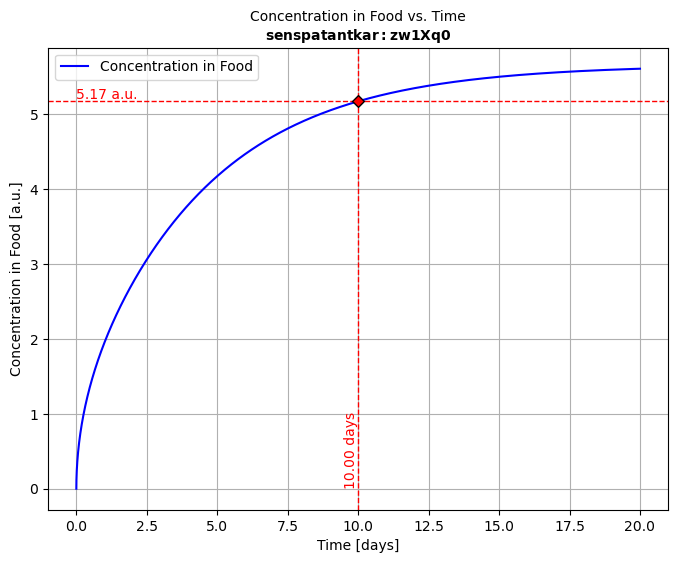

In [12]:
R = F.migration(P)  # Perform mass transfer simulation
R.plotCF()  # Plot the reference concentration profile in food

---
# Create a pseudo experiment

We create pseudo experiment by sampling `npoints=30` $C_F$ values and by adding a white noise with a standard deviation of 1% (i.e., $95\%$ of values lie within $\pm4\%$ of the simulated value).

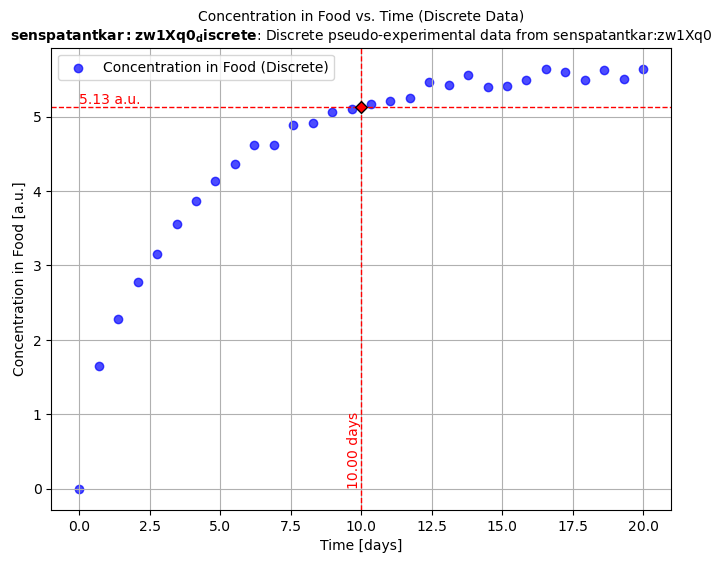

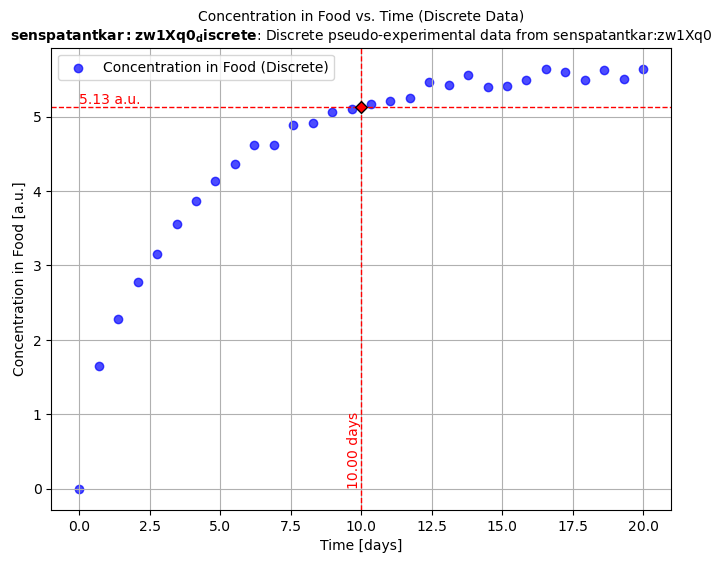

In [15]:
E = R.pseudoexperiment(npoints=30, std_relative=0.01)  # Simulated experimental dataset
E.plotCF()

## We evaluate the original distance to the experimental data
> This distance represents the minimal distance between the experiment and a model to justify that the model is as good as the experiment.

In [17]:
d2 = R - E  # Compute squared error function
d2_original = d2()  # Evaluate initial deviation from experiment
print(f"Initial squared distance (E-R)**2: {d2_original}")

Initial squared distance (E-R)**2: 1.566952672427376


---
# Sensitivity Analysis

## We change $D$ and $k$ values in 10 steps
> The effects on the migration kinetics are reported. The distance is several magnitude orders larger than the original distance. The **final values** of $D$ and $k$ will be used as initial guess to recover the **original ones**.

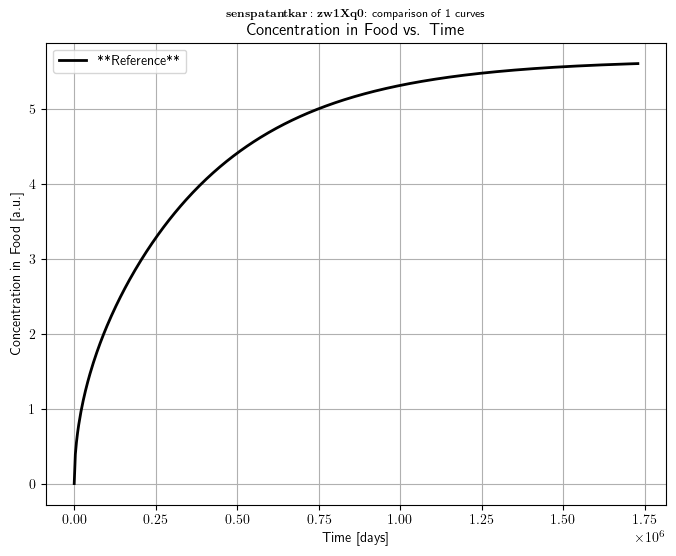

[1/10]: Distance variation = 476.15%
[2/10]: Distance variation = 1995.88%
[3/10]: Distance variation = 4742.79%
[4/10]: Distance variation = 8907.82%
[5/10]: Distance variation = 14685.37%
[6/10]: Distance variation = 22268.60%
[7/10]: Distance variation = 31843.94%
[8/10]: Distance variation = 43585.37%
[9/10]: Distance variation = 57648.59%
[10/10]: Distance variation = 74165.72%


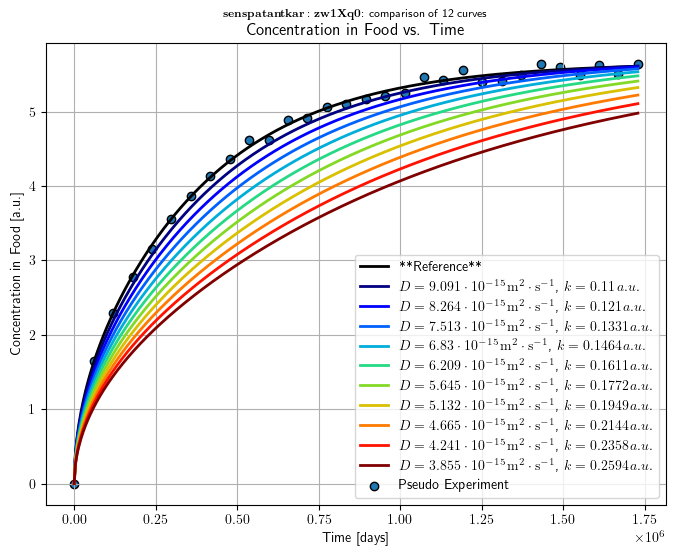

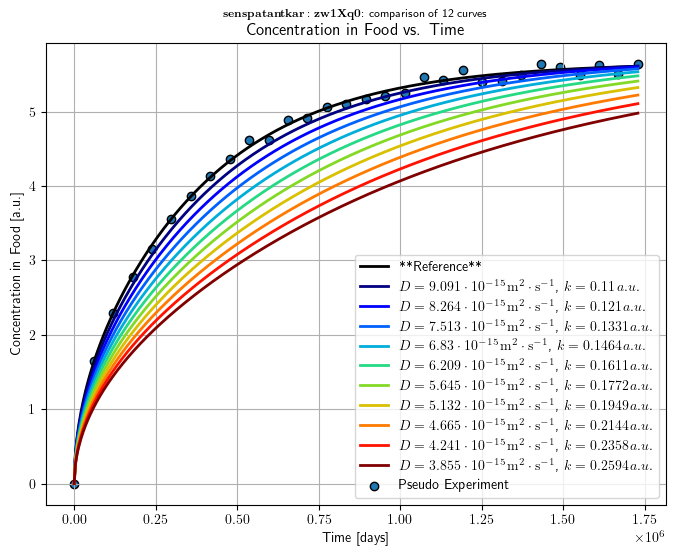

In [20]:
R.comparison.update(0, label="**Reference**", color="black")
R.comparison.plotCF()

# Set iteration count and color mapping
niterations = 10
cmap = R.comparison.jet(niterations)

# Vary D and k systematically
for i in range(1, niterations + 1):
    D[0] = D[0] / 1.1  # Decrease D by 10%
    k[0] = k[0] * 1.1  # Increase k by 10%

    # Format LaTeX labels for D and k
    name = f"{P.Dlatex()[0]}, {P.klatex()[0]}"

    # Rerun simulation with updated parameters
    R.rerun(name=name, color=cmap[i-1])

    # Compute new squared distance
    d2new = d2()
    print(f"[{i}/{niterations}]: Distance variation = {100 * d2new / d2_original - 100:.2f}%")

# Add pseudo-experimental data to comparison
R.comparison.add(E, label="Pseudo Experiment", discrete=True)
R.comparison.plotCF()  # Final visualization

---
# Fitting of migration kinetics 
> Since we are using `layerLink` objects for $D$ and $k$. No parameterization is needed.

## The method `fit`
> Note that the method `fit` must be started from `R` and not from `E`. Only `R` refers to the model.

In [23]:
d2beforeOptim = d2()  # Distance before fitting
resfit = R.fit(E)  # Perform parameter fitting
d2afterOptim = d2()  # Distance after fitting

Fitting Iteration:
 D=[2.02660678e-14] [m²/s]
 k=[0.24245056] [a.u.]

Fitting Iteration:
 D=[2.02660678e-14] [m²/s]
 k=[0.24245056] [a.u.]

Fitting Iteration:
 D=[8.83937014e-15] [m²/s]
 k=[0.25503568] [a.u.]

Fitting Iteration:
 D=[8.83937014e-15] [m²/s]
 k=[0.23839508] [a.u.]

Fitting Iteration:
 D=[8.83937014e-15] [m²/s]
 k=[0.23839508] [a.u.]

Fitting Iteration:
 D=[8.83937014e-15] [m²/s]
 k=[0.23839508] [a.u.]

Fitting Iteration:
 D=[9.8053893e-15] [m²/s]
 k=[0.24605567] [a.u.]

Fitting Iteration:
 D=[9.8053893e-15] [m²/s]
 k=[0.23000099] [a.u.]

Fitting Iteration:
 D=[9.3098585e-15] [m²/s]
 k=[0.23814387] [a.u.]

Fitting Iteration:
 D=[9.3098585e-15] [m²/s]
 k=[0.22260543] [a.u.]

Fitting Iteration:
 D=[9.3098585e-15] [m²/s]
 k=[0.22260543] [a.u.]

Fitting Iteration:
 D=[9.55441191e-15] [m²/s]
 k=[0.21510722] [a.u.]

Fitting Iteration:
 D=[9.3098585e-15] [m²/s]
 k=[0.20808084] [a.u.]

Fitting Iteration:
 D=[9.67908717e-15] [m²/s]
 k=[0.19109931] [a.u.]

Fitting Iteration:
 D=[9.3

## Print optimization results

In [25]:
print(f"BEFORE OPTIMIZATION: Distance (E-R)**2 = {d2beforeOptim}")
print(f"AFTER OPTIMIZATION: Distance (E-R)**2 = {d2afterOptim}")
overfitting_flag = "[Overfitting detected]" if d2afterOptim < d2_original else ""
print(f"Variation with original = {100 * d2afterOptim / d2_original - 100:.4g}% {overfitting_flag}\n")
print(f"Fitted D = {D.values} [m²/s] vs. Original D = {Dreference} [m²/s]")
print(f"Fitted k = {k.values} [a.u.] vs. Original k = {kreference} [a.u.]")

BEFORE OPTIMIZATION: Distance (E-R)**2 = 1163.708690803159
AFTER OPTIMIZATION: Distance (E-R)**2 = 1.5432877416070716
Variation with original = -1.51% [Overfitting detected]

Fitted D = [1.00530302e-14] [m²/s] vs. Original D = [1.e-14] [m²/s]
Fitted k = [0.09588092] [a.u.] vs. Original k = [0.1] [a.u.]


## Plot optimized results

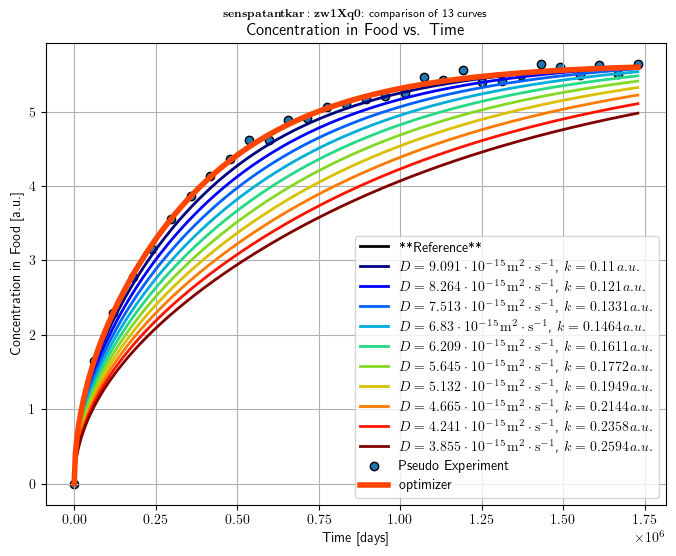

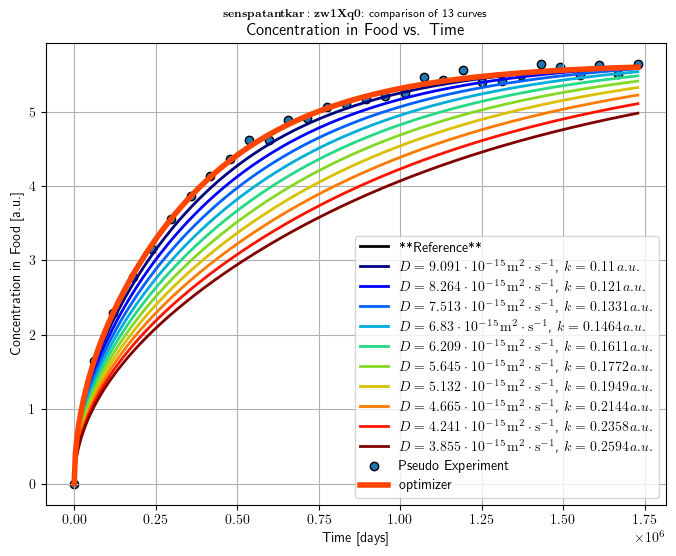

In [27]:
R.comparison.plotCF()

et voilà